<a href="https://colab.research.google.com/github/hersh-4/CSC-442-Group-Project/blob/main/CSC_442_Query_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Loading in the dataset
df = pd.read_csv('/merged_dataset.csv')

# I'm defining the target variable assigning a 1 for GOP and 0 for DEM
# Republican = GOP
df['party'] = (df['votes_gop'] > df['votes_dem']).astype(int)

# These are our annual economic indicators in our dataset
features = ['median_family_income', 'Annual Total', 'Annual Taxes',
            'Annual Housing', 'Annual Food', 'Annual Transportation',
            'Annual Healthcare', 'Annual Childcare']
X = df[features]
y = df['party']

# If a value is missing, it will fill with the median value
X = X.fillna(X.median())

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Using our testing data to make predicitons
y_pred = clf.predict(X_test)

# Evaluating the model and printing the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.85


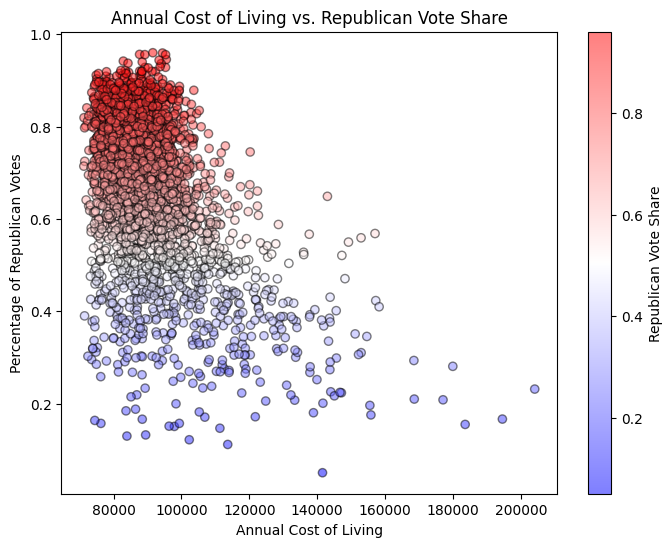

In [26]:
#Creating a scatterplot to show the relationship between the annual cost of living and the republican vote share
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Total'], df['per_gop'], alpha=0.5, c=df['per_gop'], cmap='bwr', edgecolors='k')
plt.xlabel('Annual Cost of Living')
plt.ylabel('Percentage of Republican Votes')
plt.title('Annual Cost of Living vs. Republican Vote Share')
plt.colorbar(label='Republican Vote Share')
plt.show()

<ipython-input-22-95bb2ffee54a>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['party'], y=df['median_family_income'], palette="bwr", inner="quartile")


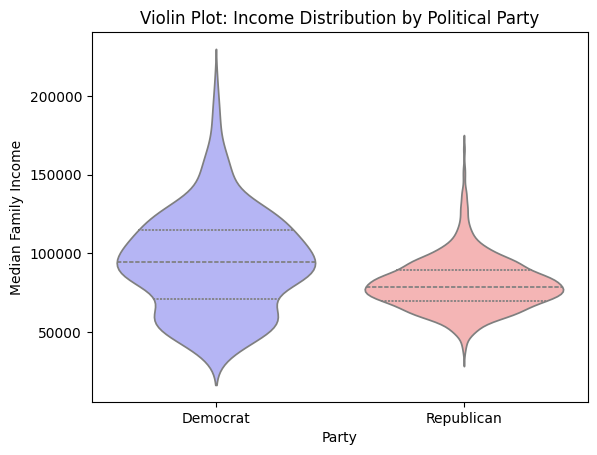

In [22]:
#Creating a violin plot to show the variation in the income distribution between the two political parties
sns.violinplot(x=df['party'], y=df['median_family_income'], palette="bwr", inner="quartile")
plt.xticks([0, 1], ["Democrat", "Republican"])
plt.xlabel("Party")
plt.ylabel("Median Family Income")
plt.title("Violin Plot: Income Distribution by Political Party")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')